In [1]:
import utils
from utils import DataGenerator, Reservoir
import pyro as py
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
Time_steps = 1500
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()
X.shape, Y.shape

((1500, 1), (1500, 1))

In [3]:
X_train = X[:1000,:]
X_test = X[1000:,:]
X_train.shape, X_test.shape

((1000, 1), (500, 1))

Input shape: (1000, 1)
Reservoir States shape: (1000, 500)


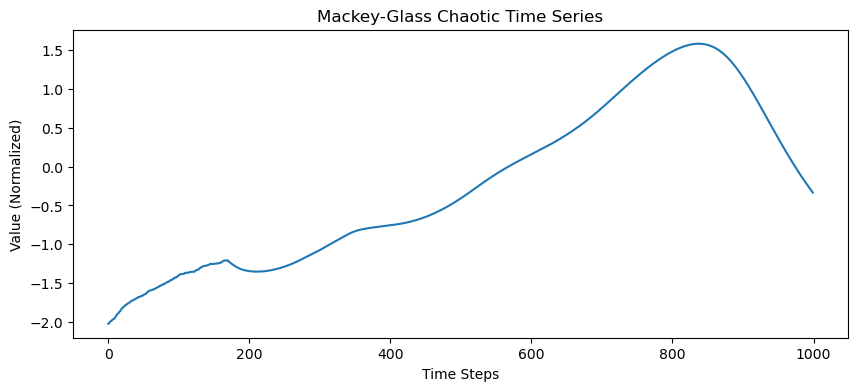

In [4]:
input_dim = X_train.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

plt.figure(figsize=(10, 4))
plt.plot(X_train)
plt.title("Mackey-Glass Chaotic Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.show()

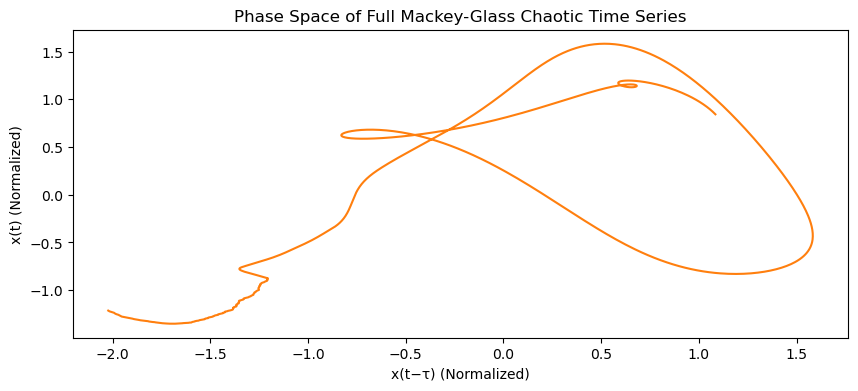

In [5]:
delay_steps = int(tau / delta_t)

plt.figure(figsize=(10, 4))
plt.plot(X[:-delay_steps], X[delay_steps:], color='C1')
plt.title("Phase Space of Full Mackey-Glass Chaotic Time Series")
plt.xlabel("x(t−τ) (Normalized)")
plt.ylabel("x(t) (Normalized)")
plt.show()

In [6]:
n_components = 16

S_train_PCA, S_test_PCA = utils.get_reduced_states(Reservoir(input_dim, reservoir_dim, spectral_radius, seed), X_train, X_test, n_components)

Original dim: (1000, 500)
Reduced dim:  (1000, 16)


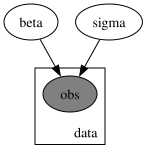

In [7]:
from methods import model
import pyro 
Y_train = Y[:1000]
pyro.render_model(model, model_args=(S_train, Y_train, [0,10.], [0,10.]))

$
\text{TotalCost}_{\text{HMC}} \approx (\text{Num Samples})\times(\text{Leapfrog Steps per Sample})\times(\text{Gradient Cost}),
$
with:
+ $\text{Gradient Cost} \sim \texttt{TimeSteps}\times\texttt{input\_dim}$
+ $\text{Leapfrog Steps} \sim \operatorname{O}(\texttt{input\_dim})$

Thus run $\text{HMC}$ sampler to sample $Y$. Two parameters will be shown. The $\texttt{step size}\,\,\Delta t$ is the integration step by used by the Leapfrog integrator. Pyro automatically identifies the value that allow to safely explore the whole distribution. The $\texttt{acc. prob}$ which is the frequency with which the sampler accepts the new proposed state at the end of a trajectory.

In [8]:
num_samples = int(2*Time_steps)

nut_kernel = pyro.infer.NUTS(model)
mcmc = pyro.infer.MCMC(nut_kernel, num_samples=num_samples, warmup_steps=200)
mcmc.run(S_train_PCA, Y_train)

Warmup:   0%|          | 0/3200 [00:00, ?it/s]

Sample: 100%|██████████| 3200/3200 [02:41, 19.80it/s, step size=6.92e-02, acc. prob=0.944]


In [9]:
param_samples = mcmc.get_samples()

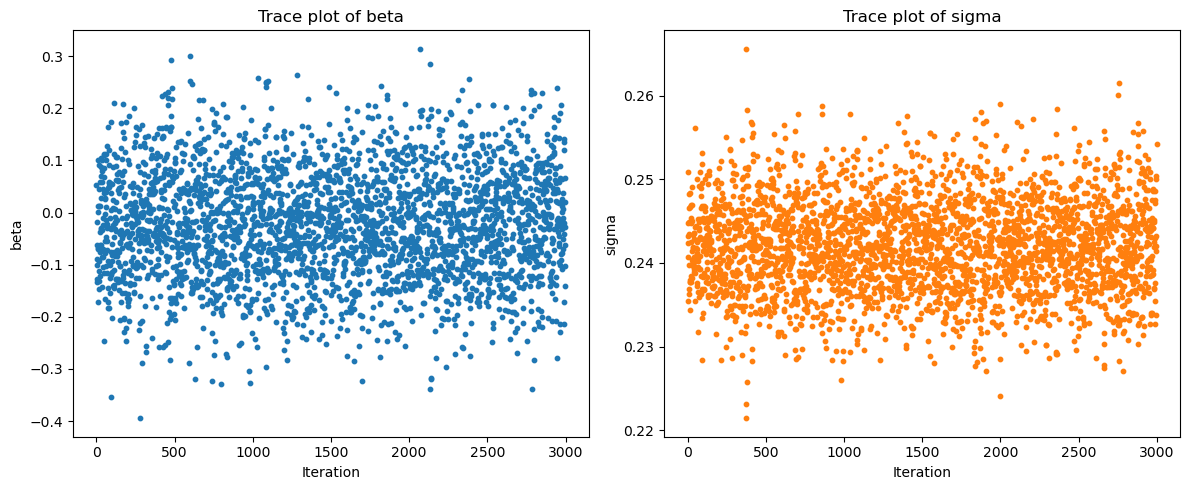

In [10]:
beta_samples = param_samples['beta'].squeeze().mean(1)
sigma_samples = param_samples['sigma'].squeeze()

iterations = np.arange(len(beta_samples))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(iterations, beta_samples, s=10, alpha=1)
plt.xlabel("Iteration")
plt.ylabel("beta")
plt.title("Trace plot of beta")

plt.subplot(1,2,2)
plt.scatter(iterations, sigma_samples, s=10, alpha=1, color="C1")
plt.xlabel("Iteration")
plt.ylabel("sigma")
plt.title("Trace plot of sigma")

plt.tight_layout()
plt.show()

In [11]:
# # Noice plotting
# import arviz as az
# az.plot_trace(mcmc)

The trajectory outlines a Posterior Predictive Distribution that allows to estimate the uncertainty in the MAP estimates in $\beta$ and $\sigma$, which is the ultimate goal of our Bayesian Reservoir Computer.

In [12]:
# # For quick fixes (to be commented out)

# def model(S, Y=None, beta_params=[0,1], sigma_params=[0,1]):

#     rows, cols = S.shape

#     S = torch.asarray(S, dtype = torch.float64)
#     if Y is not None: Y = torch.asarray(Y, dtype = torch.float64).squeeze()

#     beta = pyro.sample(
#         "beta",
#         pyro.distributions.Normal(
#             torch.tensor(beta_params[0], dtype=torch.float64),
#             torch.tensor(beta_params[1], dtype=torch.float64)
#         ).expand([cols]).to_event(1)
#     )
#     sigma = pyro.sample(
#         "sigma",
#         pyro.distributions.Uniform(
#             torch.tensor(sigma_params[0], dtype=torch.float64),
#             torch.tensor(sigma_params[1], dtype=torch.float64)
#         )
#     )
    
#     mu = torch.matmul(beta, S.mT)

#     with pyro.plate("data", rows):
#         pyro.sample(
#             "obs",
#             pyro.distributions.Normal(mu, sigma),
#             obs=Y,
#         )

In [13]:
Y_test = Y[1000:]
predictive = pyro.infer.Predictive(model, posterior_samples=param_samples, num_samples=None, parallel=True)
y_pred_samples = predictive(S_test_PCA, None)["obs"]

print("Shape of predictions:", y_pred_samples.shape)

Shape of predictions: torch.Size([3000, 500])


In [14]:
median_prediction = y_pred_samples.median(0)[0]
mean_prediction = y_pred_samples.mean(0)
std_prediction = y_pred_samples.std(0)

# 95% Confidence Interval
lower_bound = mean_prediction - 2 * std_prediction
upper_bound = mean_prediction + 2 * std_prediction

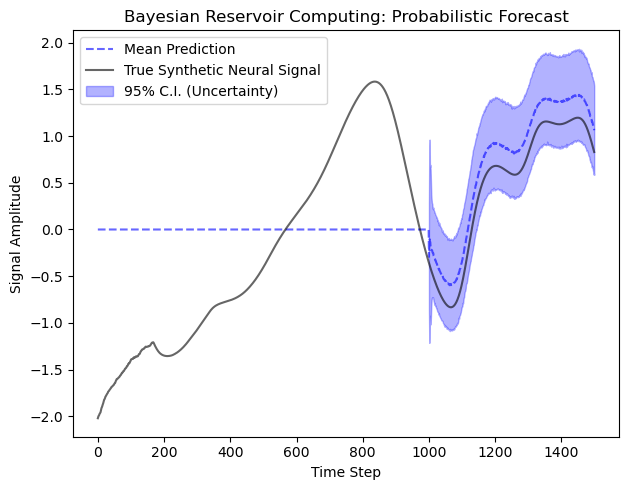

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(np.hstack((np.zeros(len(Y_train)), mean_prediction.detach().numpy())), "b--", alpha=0.6, label="Mean Prediction")
plt.plot(Y, "k-", alpha=0.6, label="True Synthetic Neural Signal")
plt.fill_between(
    range(len(Y_train), len(mean_prediction)+len(Y_train)),
    lower_bound,
    upper_bound,
    color="blue",
    alpha=0.3,
    label="95% C.I. (Uncertainty)"
)
plt.xlabel("Time Step")
plt.ylabel("Signal Amplitude")
plt.title("Bayesian Reservoir Computing: Probabilistic Forecast")
plt.tight_layout()
plt.legend()
plt.show()

Notice:
+ The predicted signal shows caothic dynamics (as it should), in the sense that is oscillates, aperiodically, without repeating the same pattern.
+ In a chaotic system, uncertainty is state-dependent, meaning the dynamics are predictable (narrow C.I.), for stable regions, and vice-versa for unstable regions.
+ The C.I. fully captures the true signal. The C.I. gets narrower when the signal changes direction less rapidly (iterations (100,200)).
We further test for a tighter noise interval. 

In [16]:
num_samples = 200

nut_kernel = pyro.infer.NUTS(model)
mcmc = pyro.infer.MCMC(nut_kernel, num_samples=num_samples, warmup_steps=200)

mcmc.run(S_train_PCA, Y_train, beta_params=[0,1.], sigma_params=[0,0.05])
mcmc.summary()

Sample: 100%|██████████| 400/400 [00:37, 10.60it/s, step size=1.59e-02, acc. prob=0.931]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]     -0.09      0.00     -0.09     -0.09     -0.09    197.55      1.00
   beta[1]     -0.09      0.00     -0.09     -0.09     -0.09    192.07      1.01
   beta[2]     -0.08      0.00     -0.08     -0.09     -0.08    273.05      1.00
   beta[3]      0.03      0.01      0.03      0.03      0.05    191.57      1.01
   beta[4]     -0.07      0.01     -0.07     -0.08     -0.05    159.91      1.00
   beta[5]     -0.04      0.01     -0.04     -0.07     -0.02    123.48      1.00
   beta[6]      0.05      0.01      0.05      0.03      0.08    229.49      1.00
   beta[7]      0.03      0.03      0.03     -0.01      0.07    216.50      1.00
   beta[8]      0.09      0.04      0.09      0.02      0.16    246.29      1.00
   beta[9]      0.01      0.04      0.01     -0.05      0.08    190.43      1.00
  beta[10]     -0.01      0.06     -0.01     -0.10      0.09    165.54      1.00
  beta[11]      0.11      0

In [17]:
param_samples = mcmc.get_samples()
predictive = pyro.infer.Predictive(model, posterior_samples=param_samples, num_samples=None, parallel=True)
y_pred_samples = predictive(S_test_PCA, None)["obs"]

median_prediction = y_pred_samples.median(0)[0]
mean_prediction = y_pred_samples.mean(0)
std_prediction = y_pred_samples.std(0)

lower_bound = mean_prediction - 2 * std_prediction
upper_bound = mean_prediction + 2 * std_prediction

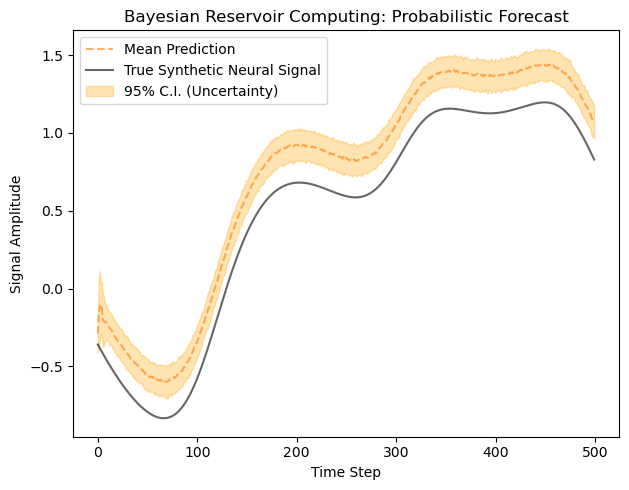

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(mean_prediction, "C1--", alpha=0.6, label="Mean Prediction")
plt.plot(Y_test, "k-", alpha=0.6, label="True Synthetic Neural Signal")
plt.fill_between(
    range(len(mean_prediction)),
    lower_bound,
    upper_bound,
    color="orange",
    alpha=0.3,
    label="95% C.I. (Uncertainty)"
)
plt.xlabel("Time Step")
plt.ylabel("Signal Amplitude")
plt.title("Bayesian Reservoir Computing: Probabilistic Forecast")
plt.tight_layout()
plt.legend()
plt.show()

For a very tightly bounded $\sigma$-prior $\sim\text{Unif}(0,<1)$, the likelihood of the data becomes effectively zero, the sampling reduces to sampling from the Prior distribution, resulting in high acceptance rates and uninformed predictions.